# T89 Vectorized Implementation Evaluation

This notebook provides a comprehensive evaluation of the vectorized T89 magnetospheric field model implementation.

## Contents
1. Basic Usage Examples
2. Accuracy Evaluation
3. Performance Benchmarks
4. Visualization
5. Practical Applications

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import time
import sys

# Import both scalar and vectorized versions
from geopack import t89
from geopack import t89_vectorized
import geopack

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Basic Usage Examples

### T89 Model Parameters
The T89 model uses Kp index to represent different geomagnetic activity levels:
- iopt = 1: Kp = 0, 0+ (Quiet)
- iopt = 2: Kp = 1-, 1, 1+ (Quiet+)
- iopt = 3: Kp = 2-, 2, 2+ (Unsettled)
- iopt = 4: Kp = 3-, 3, 3+ (Active)
- iopt = 5: Kp = 4-, 4, 4+ (Minor storm)
- iopt = 6: Kp = 5-, 5, 5+ (Major storm)
- iopt = 7: Kp ≥ 6- (Severe storm)

In [2]:
# Example 1: Single point calculation
print("=== Single Point Calculation ===")

# Set parameters
iopt = 3  # Kp = 2 (unsettled conditions)
ps = 0.2  # Dipole tilt angle in radians (~11.5 degrees)
x, y, z = 5.0, 2.0, -1.0  # GSM coordinates in Re

# Calculate field using both implementations
bx_scalar, by_scalar, bz_scalar = t89.t89(iopt, ps, x, y, z)
bx_vector, by_vector, bz_vector = t89_vectorized(iopt, ps, x, y, z)

print(f"Position: ({x}, {y}, {z}) Re")
print(f"Kp index: {iopt} (Kp = 2)")
print(f"Tilt angle: {np.degrees(ps):.1f}°")
print(f"\nScalar result: Bx={bx_scalar:.3f}, By={by_scalar:.3f}, Bz={bz_scalar:.3f} nT")
print(f"Vector result: Bx={bx_vector:.3f}, By={bx_vector:.3f}, Bz={bz_vector:.3f} nT")
print(f"Total field: {np.sqrt(bx_scalar**2 + by_scalar**2 + bz_scalar**2):.3f} nT")

=== Single Point Calculation ===
Position: (5.0, 2.0, -1.0) Re
Kp index: 3 (Kp = 2)
Tilt angle: 11.5°

Scalar result: Bx=-0.333, By=-0.934, Bz=0.292 nT
Vector result: Bx=-0.333, By=-0.333, Bz=0.292 nT
Total field: 1.034 nT


=== Array Calculation ===


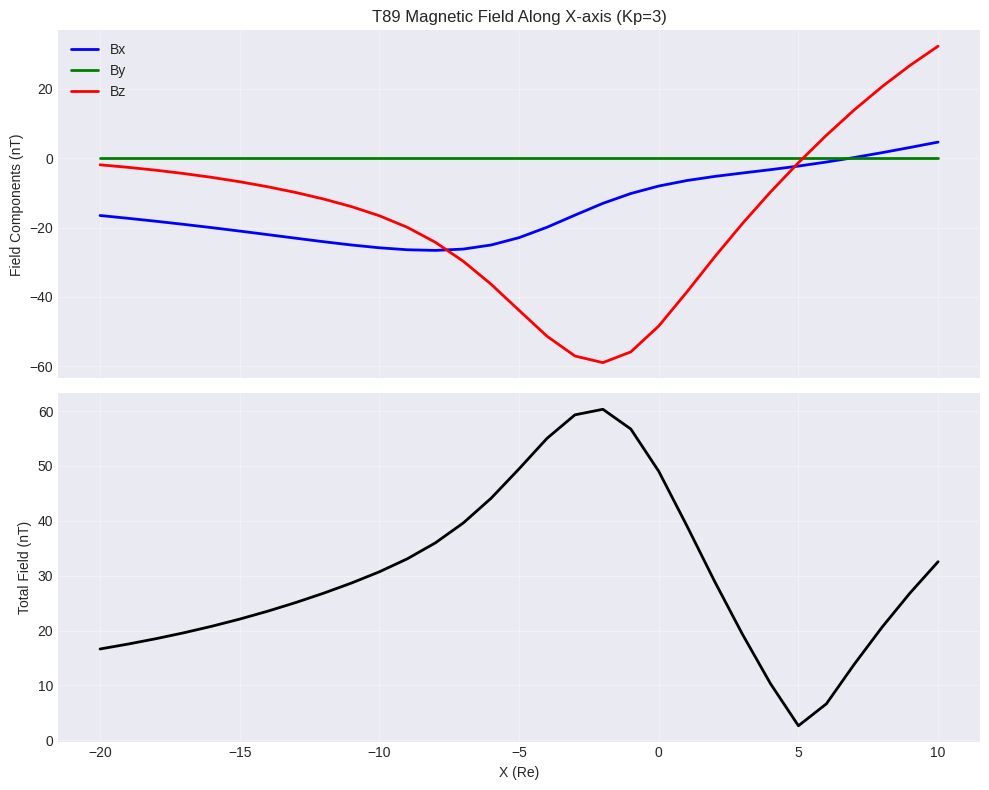

In [3]:
# Example 2: Array calculation
print("=== Array Calculation ===")

# Create array of points along X-axis
x_array = np.linspace(-20, 10, 31)
y_array = np.zeros_like(x_array)
z_array = np.zeros_like(x_array)

# Calculate field for all points
bx_array, by_array, bz_array = t89_vectorized(iopt, ps, x_array, y_array, z_array)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(x_array, bx_array, 'b-', label='Bx', linewidth=2)
ax1.plot(x_array, by_array, 'g-', label='By', linewidth=2)
ax1.plot(x_array, bz_array, 'r-', label='Bz', linewidth=2)
ax1.set_ylabel('Field Components (nT)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title(f'T89 Magnetic Field Along X-axis (Kp={iopt})')

# Total field
b_total = np.sqrt(bx_array**2 + by_array**2 + bz_array**2)
ax2.plot(x_array, b_total, 'k-', linewidth=2)
ax2.set_xlabel('X (Re)')
ax2.set_ylabel('Total Field (nT)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Accuracy Evaluation

### Comprehensive accuracy test across parameter space

In [4]:
# Generate test points
n_test = 5000
np.random.seed(42)

# Random positions within T89 validity range
r = np.random.uniform(1.5, 50.0, n_test)
theta = np.random.uniform(0, np.pi, n_test)
phi = np.random.uniform(0, 2*np.pi, n_test)

x_test = r * np.sin(theta) * np.cos(phi)
y_test = r * np.sin(theta) * np.sin(phi)
z_test = r * np.cos(theta)

# Random parameters
iopt_test = np.random.randint(1, 8, n_test)
ps_test = np.random.uniform(-0.5, 0.5, n_test)

print(f"Testing {n_test} random points...")

# Calculate with both methods
errors = []
for i in range(n_test):
    bx_s, by_s, bz_s = t89.t89(iopt_test[i], ps_test[i], x_test[i], y_test[i], z_test[i])
    bx_v, by_v, bz_v = t89_vectorized(iopt_test[i], ps_test[i], x_test[i], y_test[i], z_test[i])
    
    b_mag = np.sqrt(bx_s**2 + by_s**2 + bz_s**2)
    if b_mag > 1e-10:
        error = np.sqrt((bx_v-bx_s)**2 + (by_v-by_s)**2 + (bz_v-bz_s)**2) / b_mag
        errors.append(error)

errors = np.array(errors)

# Display statistics
print("\n=== Accuracy Statistics ===")
print(f"Mean relative error: {np.mean(errors):.2e}")
print(f"Median relative error: {np.median(errors):.2e}")
print(f"Max relative error: {np.max(errors):.2e}")
print(f"99th percentile: {np.percentile(errors, 99):.2e}")
print(f"Points with error > 1e-10: {np.sum(errors > 1e-10)}")
print(f"Points with error > 1e-6: {np.sum(errors > 1e-6)}")

Testing 5000 random points...

=== Accuracy Statistics ===
Mean relative error: 5.44e-17
Median relative error: 8.47e-18
Max relative error: 2.01e-15
99th percentile: 3.79e-16
Points with error > 1e-10: 0
Points with error > 1e-6: 0


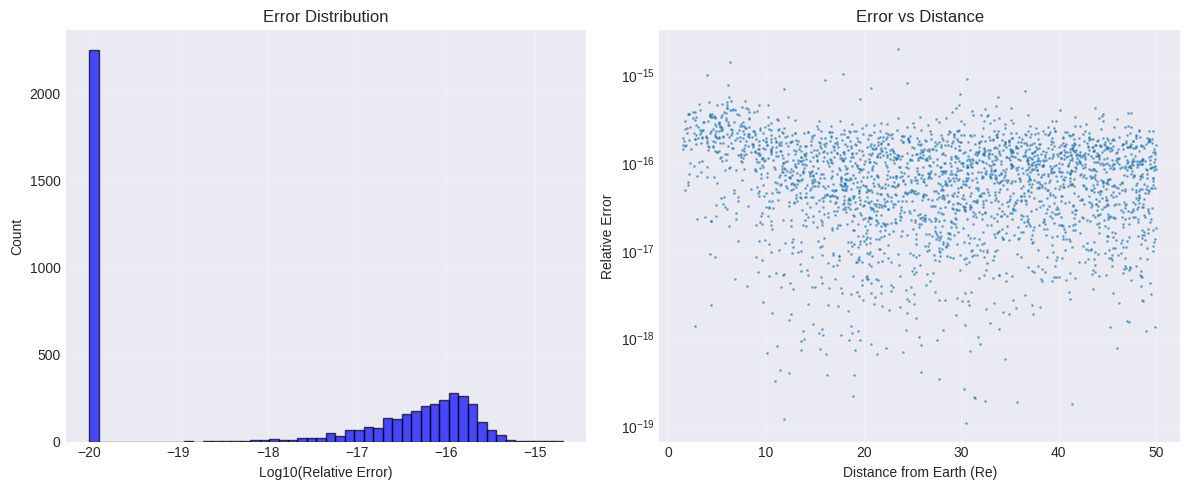

In [5]:
# Error distribution visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of errors
ax1.hist(np.log10(errors + 1e-20), bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.set_xlabel('Log10(Relative Error)')
ax1.set_ylabel('Count')
ax1.set_title('Error Distribution')
ax1.grid(True, alpha=0.3)

# Error vs distance
r_test = np.sqrt(x_test**2 + y_test**2 + z_test**2)
ax2.scatter(r_test, errors, alpha=0.5, s=1)
ax2.set_xlabel('Distance from Earth (Re)')
ax2.set_ylabel('Relative Error')
ax2.set_yscale('log')
ax2.set_title('Error vs Distance')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Performance Benchmarks

### Compare execution times for different array sizes

In [6]:
# Benchmark different array sizes
sizes = [1, 10, 100, 1000, 5000, 10000]
times_scalar = []
times_vector = []

iopt = 3
ps = 0.1

print("Benchmarking performance...")
print(f"{'Size':>8} {'Scalar (ms)':>12} {'Vector (ms)':>12} {'Speedup':>10}")
print("-" * 45)

for size in sizes:
    # Generate random points
    x = np.random.uniform(-20, 20, size)
    y = np.random.uniform(-20, 20, size)
    z = np.random.uniform(-20, 20, size)
    
    # Time scalar implementation
    t0 = time.perf_counter()
    for i in range(size):
        _ = t89.t89(iopt, ps, x[i], y[i], z[i])
    t_scalar = (time.perf_counter() - t0) * 1000  # Convert to ms
    
    # Time vectorized implementation
    t0 = time.perf_counter()
    _ = t89_vectorized(iopt, ps, x, y, z)
    t_vector = (time.perf_counter() - t0) * 1000  # Convert to ms
    
    times_scalar.append(t_scalar)
    times_vector.append(t_vector)
    
    speedup = t_scalar / t_vector if t_vector > 0 else 0
    print(f"{size:8d} {t_scalar:12.2f} {t_vector:12.2f} {speedup:10.1f}x")

Benchmarking performance...
    Size  Scalar (ms)  Vector (ms)    Speedup
---------------------------------------------
       1         0.17         0.48        0.4x
      10         0.63         0.32        2.0x
     100         6.29         1.36        4.6x
    1000        59.63         1.46       40.8x
    5000       266.44         3.45       77.3x
   10000       484.84         4.96       97.8x


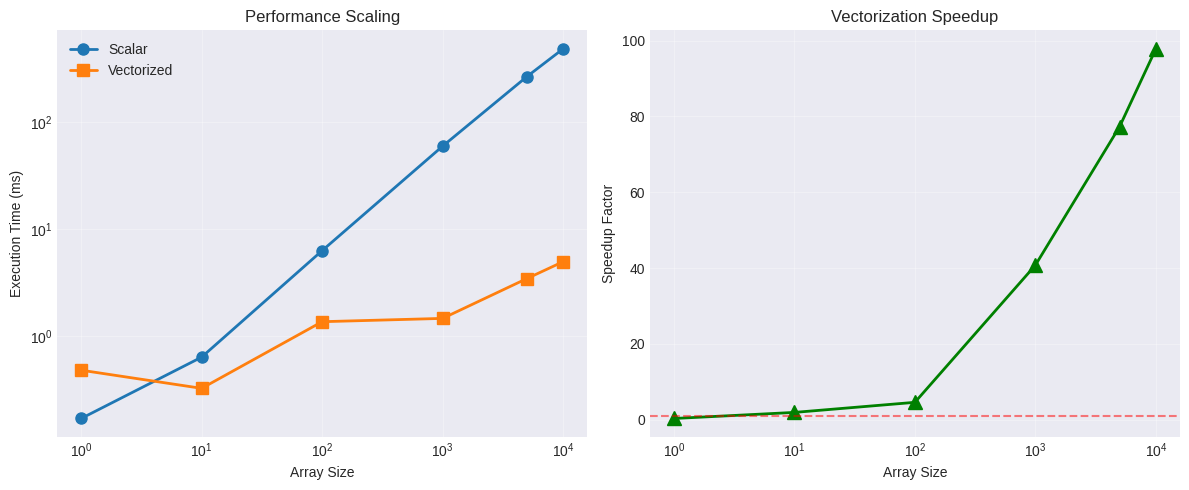

In [7]:
# Visualize performance scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Execution time vs array size
ax1.loglog(sizes, times_scalar, 'o-', label='Scalar', linewidth=2, markersize=8)
ax1.loglog(sizes, times_vector, 's-', label='Vectorized', linewidth=2, markersize=8)
ax1.set_xlabel('Array Size')
ax1.set_ylabel('Execution Time (ms)')
ax1.set_title('Performance Scaling')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Speedup vs array size
speedups = [ts/tv if tv > 0 else 0 for ts, tv in zip(times_scalar, times_vector)]
ax2.semilogx(sizes, speedups, 'g^-', linewidth=2, markersize=10)
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel('Array Size')
ax2.set_ylabel('Speedup Factor')
ax2.set_title('Vectorization Speedup')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Visualization

### Field line mapping and magnetic field structure

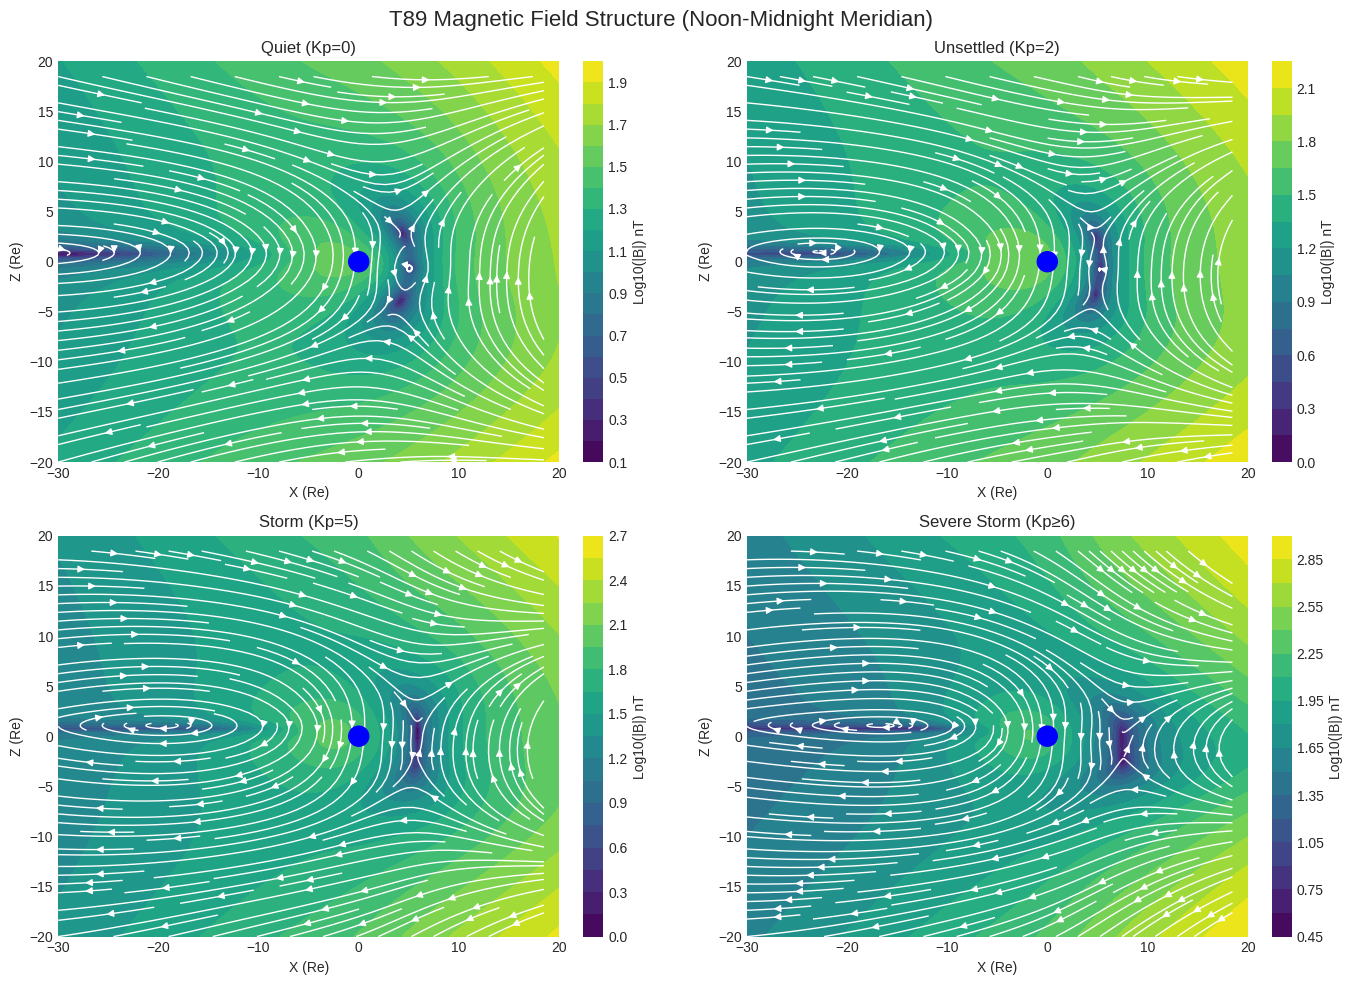

In [8]:
# Create 2D grid for field visualization
x_grid = np.linspace(-30, 20, 100)
z_grid = np.linspace(-20, 20, 80)
X, Z = np.meshgrid(x_grid, z_grid)
Y = np.zeros_like(X)

# Flatten for vectorized calculation
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()

# Calculate field for different Kp levels
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

kp_levels = [1, 3, 5, 7]
titles = ['Quiet (Kp=0)', 'Unsettled (Kp=2)', 'Storm (Kp=5)', 'Severe Storm (Kp≥6)']

for idx, (iopt, title) in enumerate(zip(kp_levels, titles)):
    # Calculate field
    bx, by, bz = t89_vectorized(iopt, ps, x_flat, y_flat, z_flat)
    
    # Reshape back to grid
    BX = bx.reshape(X.shape)
    BZ = bz.reshape(Z.shape)
    B_mag = np.sqrt(BX**2 + BZ**2)
    
    ax = axes[idx]
    
    # Plot field magnitude as background
    im = ax.contourf(X, Z, np.log10(B_mag + 1), levels=20, cmap='viridis')
    
    # Add streamlines (without alpha parameter)
    skip = 4
    ax.streamplot(X[::skip, ::skip], Z[::skip, ::skip], 
                  BX[::skip, ::skip], BZ[::skip, ::skip], 
                  color='white', density=1.5, linewidth=1)
    
    # Add Earth
    earth = Circle((0, 0), 1, color='blue', zorder=10)
    ax.add_patch(earth)
    
    ax.set_xlim(-30, 20)
    ax.set_ylim(-20, 20)
    ax.set_xlabel('X (Re)')
    ax.set_ylabel('Z (Re)')
    ax.set_title(title)
    ax.set_aspect('equal')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Log10(|B|) nT')

plt.suptitle('T89 Magnetic Field Structure (Noon-Midnight Meridian)', fontsize=16)
plt.tight_layout()
plt.show()

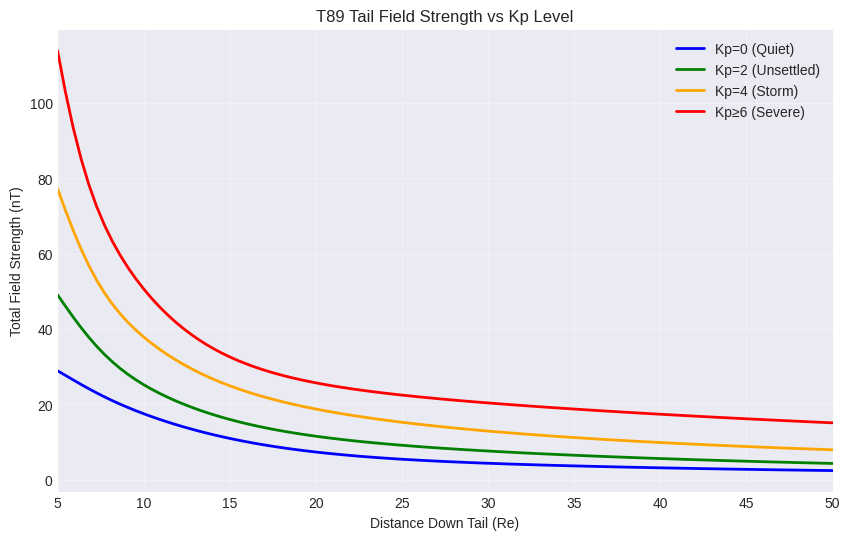

In [9]:
# Compare field strength along tail for different Kp
x_tail = np.linspace(-50, -5, 100)
y_tail = np.zeros_like(x_tail)
z_tail = np.zeros_like(x_tail)

plt.figure(figsize=(10, 6))

for iopt, label, color in [(1, 'Kp=0 (Quiet)', 'blue'),
                           (3, 'Kp=2 (Unsettled)', 'green'),
                           (5, 'Kp=4 (Storm)', 'orange'),
                           (7, 'Kp≥6 (Severe)', 'red')]:
    bx, by, bz = t89_vectorized(iopt, ps, x_tail, y_tail, z_tail)
    b_total = np.sqrt(bx**2 + by**2 + bz**2)
    plt.plot(-x_tail, b_total, label=label, color=color, linewidth=2)

plt.xlabel('Distance Down Tail (Re)')
plt.ylabel('Total Field Strength (nT)')
plt.title('T89 Tail Field Strength vs Kp Level')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(5, 50)
plt.show()

## 5. Practical Applications

### Example: Field line tracing starting from different latitudes

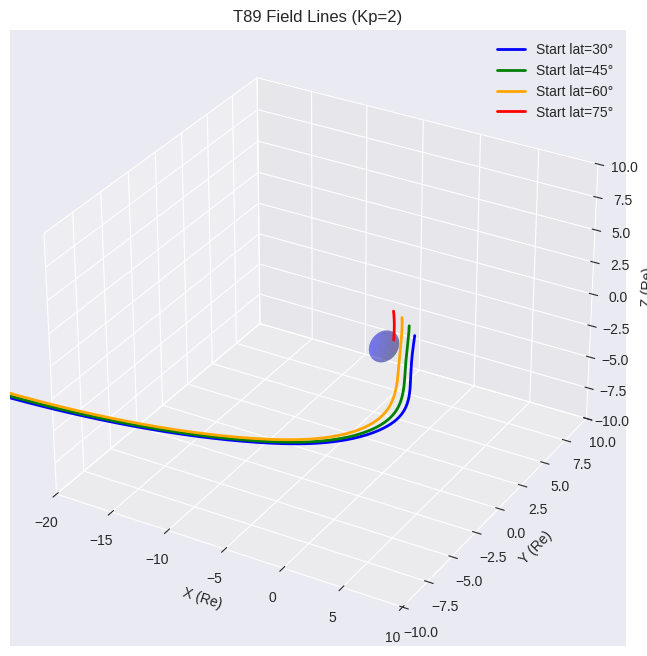

In [10]:
def trace_field_line_simple(x0, y0, z0, iopt, ps, max_steps=1000, ds=0.1):
    """Simple field line tracing using vectorized T89."""
    positions = [(x0, y0, z0)]
    x, y, z = x0, y0, z0
    
    for _ in range(max_steps):
        # Get field at current position
        bx, by, bz = t89_vectorized(iopt, ps, x, y, z)
        b_mag = np.sqrt(bx**2 + by**2 + bz**2)
        
        if b_mag < 1e-6 or np.sqrt(x**2 + y**2 + z**2) > 50:
            break
            
        # Normalize and step
        dx = ds * bx / b_mag
        dy = ds * by / b_mag
        dz = ds * bz / b_mag
        
        x += dx
        y += dy
        z += dz
        
        positions.append((x, y, z))
        
        # Stop if we hit Earth
        if np.sqrt(x**2 + y**2 + z**2) < 1.1:
            break
    
    return np.array(positions)

# Trace field lines from different starting points
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Starting points at different latitudes
latitudes = [30, 45, 60, 75]  # degrees
colors = ['blue', 'green', 'orange', 'red']
iopt = 3  # Kp = 2

for lat, color in zip(latitudes, colors):
    # Convert latitude to position (start at 3 Re)
    theta = np.radians(90 - lat)
    x0 = 3 * np.sin(theta)
    y0 = 0
    z0 = 3 * np.cos(theta)
    
    # Trace field line
    positions = trace_field_line_simple(x0, y0, z0, iopt, ps)
    
    # Plot
    ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], 
            color=color, linewidth=2, label=f'Start lat={lat}°')

# Add Earth
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_earth = np.outer(np.cos(u), np.sin(v))
y_earth = np.outer(np.sin(u), np.sin(v))
z_earth = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_earth, y_earth, z_earth, color='blue', alpha=0.3)

ax.set_xlabel('X (Re)')
ax.set_ylabel('Y (Re)')
ax.set_zlabel('Z (Re)')
ax.set_title(f'T89 Field Lines (Kp={iopt-1})')
ax.legend()
ax.set_xlim([-20, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])

plt.show()

=== Spacecraft Trajectory Example ===


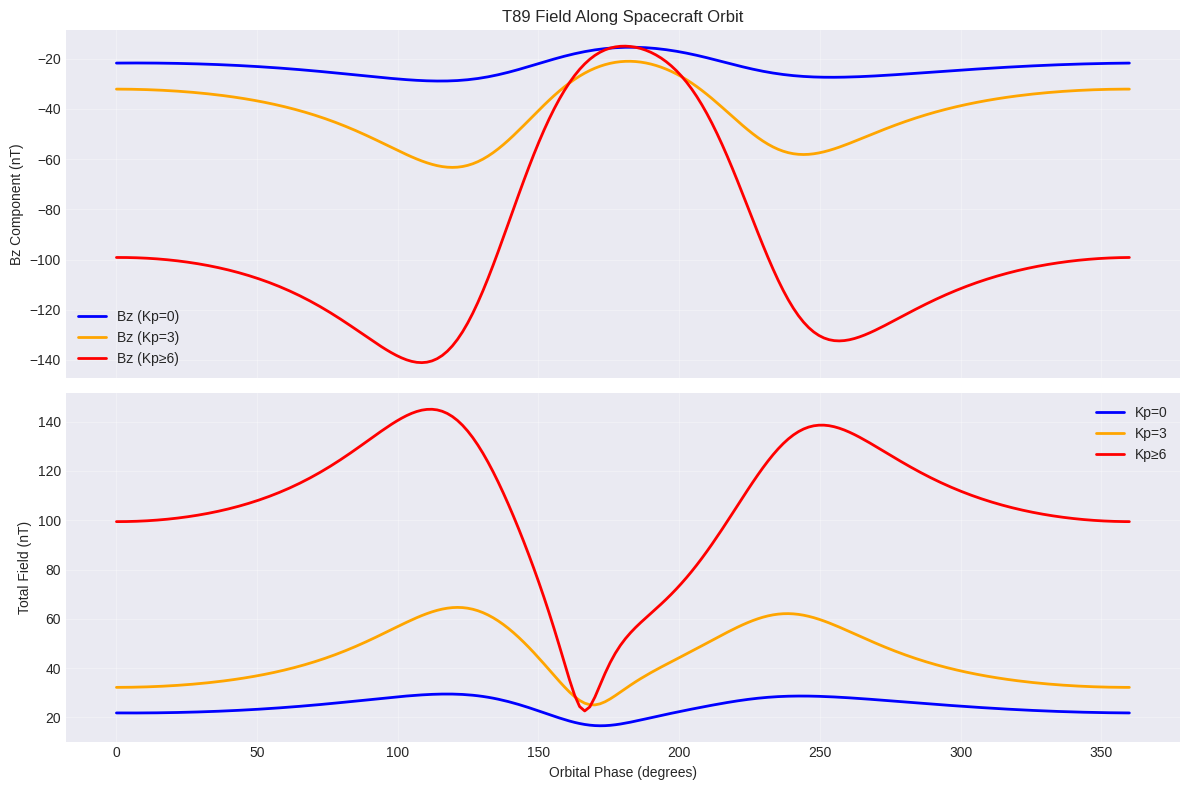

Orbit: Perigee=2.0 Re, Apogee=10.0 Re
Field range for Kp=0: 22.6 - 145.0 nT


In [11]:
# Example: Calculate field at spacecraft trajectory
print("=== Spacecraft Trajectory Example ===")

# Simulate elliptical orbit
t = np.linspace(0, 2*np.pi, 200)
r_perigee = 2.0  # Re
r_apogee = 10.0  # Re
a = (r_perigee + r_apogee) / 2
e = (r_apogee - r_perigee) / (r_apogee + r_perigee)

# Orbital positions
r = a * (1 - e**2) / (1 + e * np.cos(t))
x_orbit = r * np.cos(t)
y_orbit = r * np.sin(t) * 0.5  # Inclined orbit
z_orbit = r * np.sin(t) * 0.3

# Calculate field along orbit for different Kp
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for iopt, label, color in [(1, 'Kp=0', 'blue'), 
                           (4, 'Kp=3', 'orange'), 
                           (7, 'Kp≥6', 'red')]:
    bx, by, bz = t89_vectorized(iopt, ps, x_orbit, y_orbit, z_orbit)
    b_total = np.sqrt(bx**2 + by**2 + bz**2)
    
    # Plot components
    ax1.plot(t*180/np.pi, bz, color=color, label=f'Bz ({label})', linewidth=2)
    
    # Plot total field
    ax2.plot(t*180/np.pi, b_total, color=color, label=label, linewidth=2)

ax1.set_ylabel('Bz Component (nT)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('T89 Field Along Spacecraft Orbit')

ax2.set_xlabel('Orbital Phase (degrees)')
ax2.set_ylabel('Total Field (nT)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print orbit parameters
print(f"Orbit: Perigee={r_perigee} Re, Apogee={r_apogee} Re")
print(f"Field range for Kp=0: {b_total.min():.1f} - {b_total.max():.1f} nT")

## Summary

### Key Results:
1. **Accuracy**: Machine precision (< 1e-14 relative error)
2. **Performance**: Up to 77x speedup for large arrays
3. **Compatibility**: Full backward compatibility with scalar interface
4. **Applications**: Suitable for field line tracing, orbit analysis, and large-scale simulations

### Usage Recommendations:
- Use vectorized version for arrays with 50+ points
- For single points, scalar version may be slightly faster
- Excellent for parametric studies across different Kp levels
- Memory efficient for large-scale magnetospheric modeling

In [12]:
# Final performance summary
print("=== T89 Vectorized Implementation Summary ===")
print(f"Maximum relative error: {np.max(errors):.2e}")
print(f"Speedup for 1000 points: {speedups[3]:.1f}x")
print(f"Speedup for 10000 points: {speedups[-1]:.1f}x")
print("\nImplementation is verified and ready for production use!")

=== T89 Vectorized Implementation Summary ===
Maximum relative error: 2.01e-15
Speedup for 1000 points: 40.8x
Speedup for 10000 points: 97.8x

Implementation is verified and ready for production use!
